In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

### Zadanie 5

In [2]:
n = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5]
start_x = 5
num_iterations = 30

def function(x):
    return x**2

def gradient(x):
    return 2*x

def gradient_descent(start_x, learning_rate, num_iterations):
    x = start_x
    history = {'x': [x], 'f': [function(x)]}

    for i in range(num_iterations):
        grad = gradient(x)
        x = x - learning_rate * grad
        history['x'].append(x)
        history['f'].append(function(x))

    return history

histories = {}
for key, value in enumerate(n):
    histories[key] = gradient_descent(start_x, value, num_iterations)

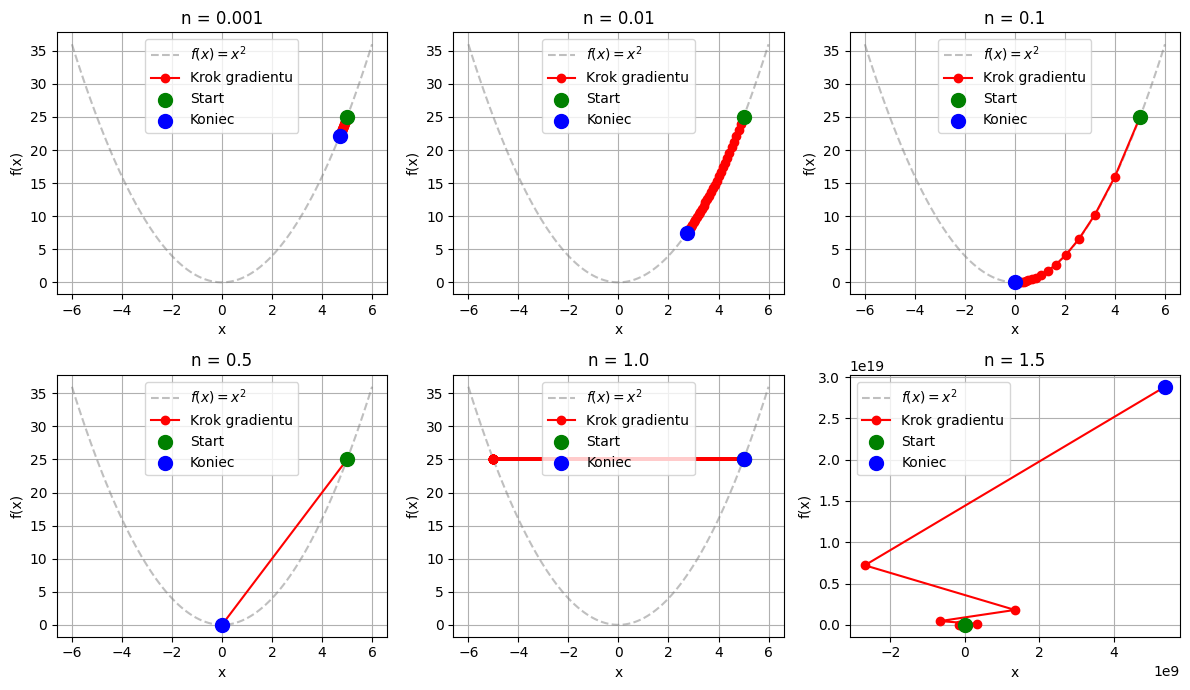

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

x_vals = np.linspace(-6, 6, 100)
y_vals = function(x_vals)

for i, val in enumerate(n):
    ax = axes[i]
    history = histories[i]

    # Wykres funkcji tła
    ax.plot(x_vals, y_vals, color='gray', linestyle='--', alpha=0.5, label='$f(x)=x^2$')

    # Punkty z historii (jeden krok ze względu na return w pętli)
    hx = history['x']
    hf = history['f']
    ax.plot(hx, hf, 'ro-', label='Krok gradientu')
    ax.scatter(hx[0], hf[0], color='green', s=100, label='Start', zorder=5)
    ax.scatter(hx[-1], hf[-1], color='blue', s=100, label='Koniec', zorder=5)

    ax.set_title(f'n = {val}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Optymalny Learning Rate to n = 0.1.
Jako jedyny pozwolił algorytmowi na dotarcie do minimum funkcji w założonej liczbie iteracji oraz nie był efektem przypadku (jak dla n = 5).
Niższe LR powodowały zbyt wolne schodzenie algorytmu - wymagają dużo wyższej liczby iteracji.
Wyższe natomiast, prowadziły do oscylacji algorytmu.

### Zadanie 9

In [4]:
X, y = make_regression(n_samples=200, n_features=1, noise=20)
X = X.flatten()
y = y.flatten()

#y
def predict(X, w, b):
    #w=a
    return w * X + b

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def compute_gradient(X, y, w, b):
    n = len(y)
    y_pred = predict(X, w, b)
    err = y - y_pred
    dw = (-2/n) * np.sum((err * X))
    db = (-2/n) * np.sum((err))
    return dw, db

def gradient_descent_linear(X, y, learning_rate, num_iterations):
    w = np.random.randn()
    b = np.random.randn()

    history = {'w': [w], 'b': [b], 'loss': [compute_mse(y, predict(X, w, b))]}

    for i in range(num_iterations):
        dw, db = compute_gradient(X, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

        loss = compute_mse(y, predict(X, w, b))
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(loss)

    return w, b, history

w_final, b_final, history = gradient_descent_linear(X, y, learning_rate=0.01, num_iterations=10000)


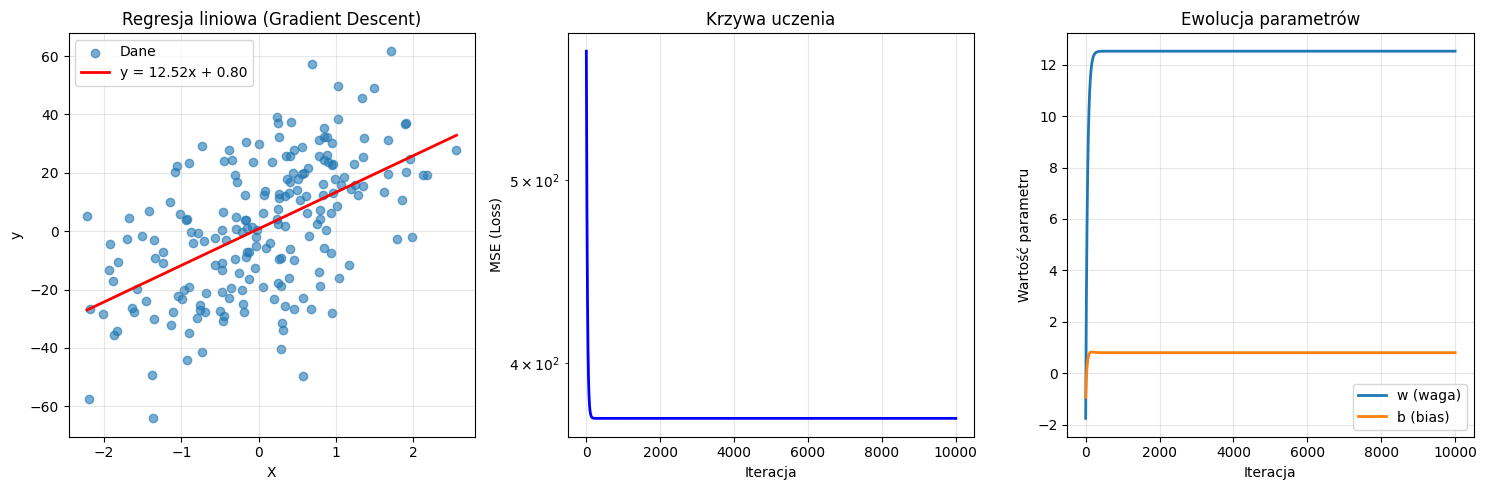

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X, y, alpha=0.6, label='Dane')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, predict(x_line, w_final, b_final), 'r-',
linewidth=2, label=f'y = {w_final:.2f}x + {b_final:.2f}')

axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Regresja liniowa (Gradient Descent)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history['loss'], 'b-', linewidth=2)
axes[1].set_xlabel('Iteracja')
axes[1].set_ylabel('MSE (Loss)')
axes[1].set_title('Krzywa uczenia')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['w'], label='w (waga)', linewidth=2)
axes[2].plot(history['b'], label='b (bias)', linewidth=2)
axes[2].set_xlabel('Iteracja')
axes[2].set_ylabel('Wartość parametru')
axes[2].set_title('Ewolucja parametrów')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
model_sk = LinearRegression().fit(X.reshape(-1, 1), y)
print(f"w: {model_sk.coef_[0]}, b: {model_sk.intercept_}")

w: 12.524440472457442, b: 0.7978375093624399
